In [3]:
backtest_file = '/allah/stuff/freq/project_2/user_data/backtest_results/extracted_2025-03-18_16-15-33/backtest-result-2025-03-18_16-15-33.json'

import json
import pandas as pd
from datetime import datetime

# Load the backtest results
with open(backtest_file, 'r') as f:
    backtest_data = json.load(f)

# Create DataFrame from backtest data
df = pd.DataFrame(backtest_data)


ValueError: Mixing dicts with non-Series may lead to ambiguous ordering.

Found 495 trades in the backtest results.
Average trade duration: 4.09 seconds

=== Basic Trade Statistics ===
Total trades: 495
Profitable trades: 176 (35.56%)
Average profit: -0.20%
Max profit: 60.73%
Max loss: -17.43%

=== Trade Direction Statistics ===
Long trades: 252
  Win rate: 36.51%
  Average profit: 0.32%
Short trades: 243
  Win rate: 34.57%
  Average profit: -0.73%

=== Sample Trade Details ===


,pair,direction,open_date,close_date,open_rate,close_rate,profit_ratio,stake_amount,exit_reason
0,ETH/USDT:USDT,long,2025-03-15 00:09:40+00:00,2025-03-15 00:16:10+00:00,1910.60,1911.91,0.085706,7424.989005,trailing_stop_loss
1,ETH/USDT:USDT,short,2025-03-15 00:13:15+00:00,2025-03-15 00:16:35+00:00,1913.16,1913.78,-0.040509,2475.001524,trailing_stop_loss
2,ETH/USDT:USDT,short,2025-03-15 00:17:40+00:00,2025-03-15 00:18:10+00:00,1912.45,1914.50,-0.133990,2533.231270,trailing_stop_loss
3,ETH/USDT:USDT,short,2025-03-15 00:19:15+00:00,2025-03-15 00:20:55+00:00,1914.01,1915.16,-0.075104,2197.206920,trailing_stop_loss
4,ETH/USDT:USDT,long,2025-03-15 00:16:35+00:00,2025-03-15 00:22:00+00:00,1913.08,1914.08,0.065340,7897.500333,trailing_stop_loss
5,ETH/USDT:USDT,short,2025-03-15 00:21:50+00:00,2025-03-15 00:25:20+00:00,1914.50,1914.41,0.005876,2033.826956,trailing_stop_loss
6,ETH/USDT:USDT,short,2025-03-15 00:24:10+00:00,2025-03-15 00:28:30+00:00,1913.29,1914.71,-0.092772,576.726831,trailing_stop_loss
7,ETH/USDT:USDT,short,2025-03-15 00:25:55+00:00,2025-03-15 00:28:30+00:00,1913.46,1915.11,-0.107789,2045.657124,trailing_stop_loss
8,ETH/USDT:USDT,short,2025-03-15 00:29:25+00:00,2025-03-15 00:31:25+00:00,1914.42,1916.33,-0.124711,2351.122175,stop_loss
9,ETH/USDT:USDT,long,2025-03-15 00:24:00+00:00,2025-03-15 00:31:55+00:00,1913.69,1915.26,0.102551,7831.646194,trailing_stop_loss


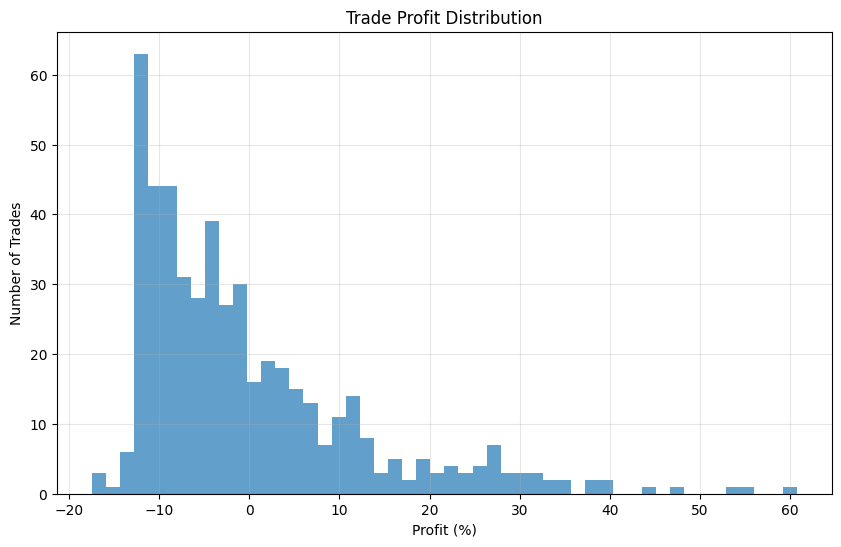

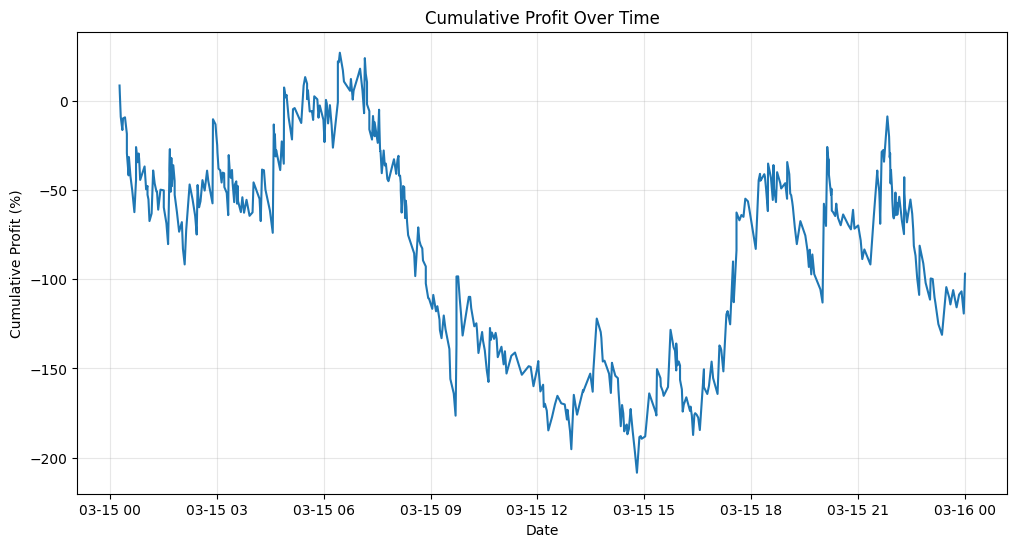


=== Exit Reasons ===
exit_reason
trailing_stop_loss    463
stop_loss              30
force_exit              2
Name: count, dtype: int64


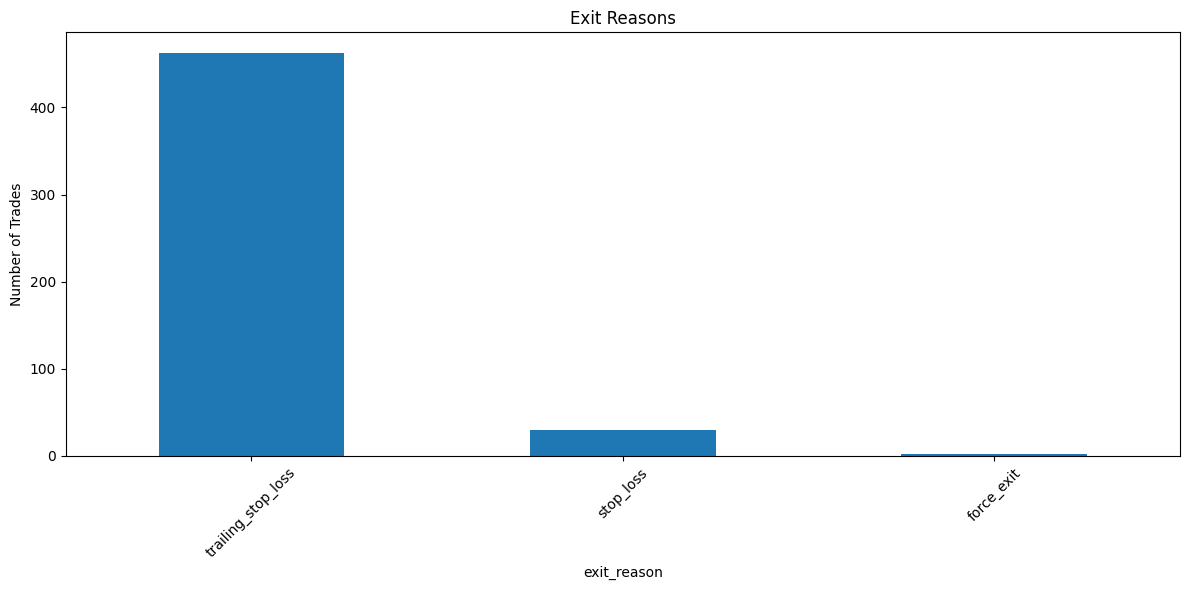


=== Profit by Exit Reason ===
                         mean       sum  count
exit_reason                                   
force_exit          11.051339  0.221027      2
trailing_stop_loss   0.550026  2.546621    463
stop_loss          -12.463474 -3.739042     30


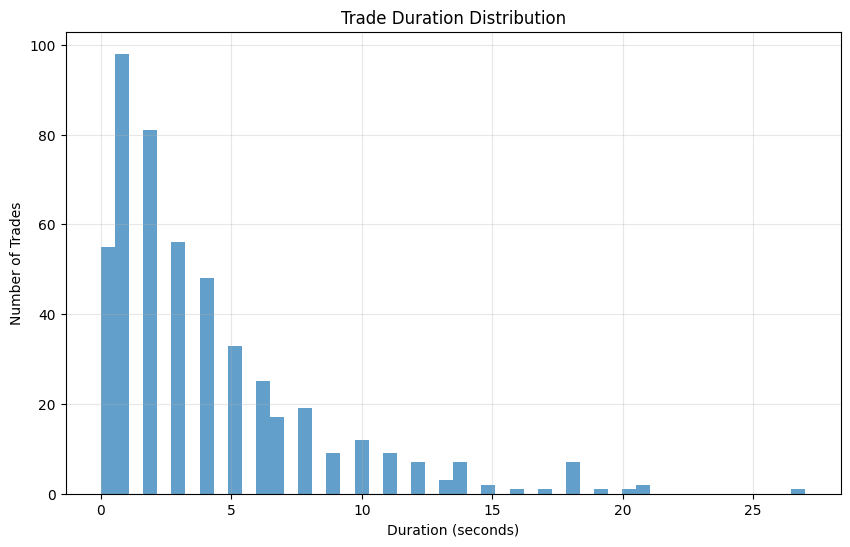

In [5]:
import json
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import os

# Path to the most recent backtest result
backtest_file = '/allah/stuff/freq/project_2/user_data/backtest_results/extracted_2025-03-18_16-20-04/backtest-result-2025-03-18_16-20-04.json'

# Check if file exists
if not os.path.exists(backtest_file):
    # Try non-extracted path
    original_file = backtest_file.replace('extracted_', '')
    if os.path.exists(original_file):
        backtest_file = original_file
    else:
        print(f"File not found: {backtest_file}")
        zip_file = backtest_file.replace('extracted_', '').replace('.json', '.zip')
        if os.path.exists(zip_file):
            print(f"Found zip file: {zip_file}. Please extract it first.")

# Load backtest data
with open(backtest_file, 'r') as f:
    backtest_data = json.load(f)

# Extract trades from the nested structure
trades = []
if 'strategy' in backtest_data:
    for strategy_name, strategy_data in backtest_data['strategy'].items():
        if 'trades' in strategy_data:
            for trade in strategy_data['trades']:
                # Add strategy name to the trade data
                trade['strategy'] = strategy_name
                trades.append(trade)

print(f"Found {len(trades)} trades in the backtest results.")

if trades:
    # Convert to DataFrame
    trades_df = pd.DataFrame(trades)
    
    # Convert date strings to datetime objects
    # Check if dates are already in string format or timestamp format
    if isinstance(trades_df['open_date'].iloc[0], str):
        trades_df['open_date'] = pd.to_datetime(trades_df['open_date'])
        trades_df['close_date'] = pd.to_datetime(trades_df['close_date'])
    else:
        # If timestamps in seconds
        trades_df['open_date'] = pd.to_datetime(trades_df['open_date'], unit='s')
        trades_df['close_date'] = pd.to_datetime(trades_df['close_date'], unit='s')
    
    # Calculate duration if not already present
    if 'trade_duration' not in trades_df.columns:
        trades_df['trade_duration'] = (trades_df['close_date'] - trades_df['open_date']).dt.total_seconds()
    
    print(f"Average trade duration: {trades_df['trade_duration'].mean():.2f} seconds")
    
    # Display basic statistics
    print("\n=== Basic Trade Statistics ===")
    print(f"Total trades: {len(trades_df)}")
    print(f"Profitable trades: {(trades_df['profit_ratio'] > 0).sum()} ({(trades_df['profit_ratio'] > 0).sum() / len(trades_df) * 100:.2f}%)")
    print(f"Average profit: {trades_df['profit_ratio'].mean() * 100:.2f}%")
    print(f"Max profit: {trades_df['profit_ratio'].max() * 100:.2f}%")
    print(f"Max loss: {trades_df['profit_ratio'].min() * 100:.2f}%")
    
    # Display statistics by trade direction (long/short)
    if 'is_short' in trades_df.columns:
        print("\n=== Trade Direction Statistics ===")
        trades_df['direction'] = trades_df['is_short'].apply(lambda x: 'short' if x else 'long')
        
        for direction in trades_df['direction'].unique():
            direction_df = trades_df[trades_df['direction'] == direction]
            profit_trades = (direction_df['profit_ratio'] > 0).sum()
            total_trades = len(direction_df)
            win_rate = profit_trades / total_trades * 100
            avg_profit = direction_df['profit_ratio'].mean() * 100
            
            print(f"{direction.capitalize()} trades: {total_trades}")
            print(f"  Win rate: {win_rate:.2f}%")
            print(f"  Average profit: {avg_profit:.2f}%")
    
    # Display the first few trades
    print("\n=== Sample Trade Details ===")
    columns_to_show = ['pair', 'direction', 'open_date', 'close_date', 
                        'open_rate', 'close_rate', 'profit_ratio', 'stake_amount', 'exit_reason']
    if 'direction' not in trades_df.columns and 'is_short' in trades_df.columns:
        columns_to_show.remove('direction')
        columns_to_show.append('is_short')
    
    # Make sure all columns exist
    columns_to_show = [col for col in columns_to_show if col in trades_df.columns]
    display(trades_df[columns_to_show].head(10))
    
    # Plot trade profit distribution
    plt.figure(figsize=(10, 6))
    plt.hist(trades_df['profit_ratio'] * 100, bins=50, alpha=0.7)
    plt.title('Trade Profit Distribution')
    plt.xlabel('Profit (%)')
    plt.ylabel('Number of Trades')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot cumulative profit over time
    plt.figure(figsize=(12, 6))
    sorted_df = trades_df.sort_values('close_date')
    cumulative_profit = sorted_df['profit_ratio'].cumsum() * 100
    plt.plot(sorted_df['close_date'], cumulative_profit)
    plt.title('Cumulative Profit Over Time')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit (%)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Summary of exit reasons
    exit_reasons = trades_df['exit_reason'].value_counts()
    print("\n=== Exit Reasons ===")
    print(exit_reasons)
    
    # Plot exit reasons
    plt.figure(figsize=(12, 6))
    exit_reasons.plot(kind='bar')
    plt.title('Exit Reasons')
    plt.ylabel('Number of Trades')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Calculate profit by exit reason
    profit_by_exit = trades_df.groupby('exit_reason')['profit_ratio'].agg(['mean', 'sum', 'count'])
    profit_by_exit['mean'] = profit_by_exit['mean'] * 100  # Convert to percentage
    profit_by_exit.sort_values('mean', ascending=False, inplace=True)
    print("\n=== Profit by Exit Reason ===")
    print(profit_by_exit)
    
    # Plot trade durations histogram
    plt.figure(figsize=(10, 6))
    # Use trade_duration directly
    plt.hist(trades_df['trade_duration'], bins=50, alpha=0.7)
    plt.title('Trade Duration Distribution')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Number of Trades')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No trades found in the backtest results.")
    # Display strategy statistics if available
    if 'strategy_comparison' in backtest_data:
        print("\nStrategy comparison:")
        for strategy, metrics in backtest_data['strategy_comparison'].items():
            print(f"\nStrategy: {strategy}")
            for metric, value in metrics.items():
                print(f"  {metric}: {value}")